# 01 - Data Preparation & EDA

This notebook contains the complete feature extraction pipeline for your GNN and VAE models:
1. **Load data** and extract Lipinski descriptors  
2. **Visualize** molecular property distributions
3. **Convert SMILES to PyG graphs** with proper node/edge features
4. **Reference pocket encoding** for VAE conditioning
5. **Save processed data** for downstream notebooks

In [1]:
# Imports and configuration
# Load shared libraries once here so the later cells can focus on analysis, graph conversion, and saving outputs.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen
import logging
import torch
from torch_geometric.data import Data

# Plot style
# Keep figures visually consistent across the notebook and the downstream reports.
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

ROOT = Path.cwd().parent
DATA_RAW = ROOT / 'data' / 'raw' / 'bioactivity'
DATA_PROCESSED = ROOT / 'data' / 'processed'
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
OUT = ROOT / 'results' / 'figures'
OUT.mkdir(parents=True, exist_ok=True)

# Route logs and derived artifacts into shared project folders so later notebooks can reuse them.
logger = logging.getLogger()
logger.setLevel(logging.INFO)
print('Working directory:', ROOT)

/Users/ameliaburton/Downloads/clean data/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Working directory: /Users/ameliaburton/Downloads/clean data/clean_data_diss


In [2]:
# Optional: Download ZINC subset (disabled by default)
DO_DOWNLOAD = False
if DO_DOWNLOAD:
    import requests
    url = 'https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/data/zinc250k.smi'
    target = DATA_RAW / 'zinc250k.smi'
    res = requests.get(url, stream=True)
    with open(target, 'wb') as f:
        for chunk in res.iter_content(chunk_size=8192):
            f.write(chunk)
    print('Downloaded', target)
else:
    print('Download skipped (set DO_DOWNLOAD=True to enable)')

Download skipped (set DO_DOWNLOAD=True to enable)


In [3]:
# ===== LOAD DATA & EXTRACT GLOBAL FEATURES: Lipinski's Rule of 5 + ADME =====

def extract_global_features(smiles_list, pic50_list=None):
    """Extracts expanded molecular descriptors (Lipinski + ADME properties)."""
    rows = []
    for i, smiles in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            continue
        row = {
            'SMILES': smiles,
            'MolWt': Descriptors.MolWt(mol),
            'LogP': Crippen.MolLogP(mol),
            'NumHDonors': Descriptors.NumHDonors(mol),
            'NumHAcceptors': Descriptors.NumHAcceptors(mol),
            'TPSA': Descriptors.TPSA(mol),                           # Topological polar surface area
            'RotatableBonds': Descriptors.NumRotatableBonds(mol),    # Molecular flexibility
        }
        if pic50_list is not None and i < len(pic50_list):
            row['pIC50'] = pic50_list[i]
        rows.append(row)
    return pd.DataFrame(rows)

# Load bioactivity data
raw_csv = DATA_RAW / 'egfr_full_standardized.csv'
if raw_csv.exists():
    df = pd.read_csv(raw_csv)
    print(f'✓ Loaded {raw_csv.name} with {len(df)} rows')
    pic50_list = df.get('pChEMBL_Value', None)
    df_global = extract_global_features(df['Smiles'].tolist(), pic50_list.tolist() if pic50_list is not None else None)
    print(f'\nGlobal Features Table (shape={df_global.shape}):')
    print(df_global.head())
else:
    print('⚠ Raw CSV not found; creating sample dataset')
    df = pd.DataFrame({
        'Smiles': ['CCO', 'CC(=O)O', 'CCN', 'CCCl', 'c1ccccc1'],
        'pChEMBL_Value': [6.5, 5.2, 7.1, 4.8, 6.9]
    })
    df_global = extract_global_features(df['Smiles'].tolist(), df['pChEMBL_Value'].tolist())
    print(f'Sample Data (shape={df_global.shape}):')
    print(df_global)


✓ Loaded egfr_full_standardized.csv with 20933 rows


[16:20:20] improperly formatted w block



Global Features Table (shape=(20909, 8)):
                                              SMILES    MolWt     LogP  \
0  Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...  383.814  4.45034   
1  Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...  482.903  3.61432   
2        CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12  369.432  4.77200   
3             CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1  283.287  2.31056   
4                             O=C(O)/C=C/c1ccc(O)cc1  164.160  1.49000   

   NumHDonors  NumHAcceptors    TPSA  RotatableBonds     pIC50  
0           3              4   82.70               3  7.387216  
1           3              6  112.24               4  6.769551  
2           1              6   78.66               6  5.031517  
3           2              4  113.98               5  3.301030  
4           2              2   57.53               2  2.522879  


In [4]:
# ===== FEATURE INSPECTION: describe().T and quality checks =====

from IPython.display import display

feature_cols = ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA', 'pIC50']
feature_cols = [col for col in feature_cols if col in df_global.columns]

if feature_cols:
    df_property = df_global[feature_cols].copy()
    summary = df_property.describe().T
    summary['missing'] = df_property.isna().sum()
    summary['nunique'] = df_property.nunique()
    summary['skew'] = df_property.skew(numeric_only=True)
    summary['kurtosis'] = df_property.kurtosis(numeric_only=True)

    print('✓ Feature summary (describe().T):')
    display(summary)

    print('\n✓ Missing values by feature:')
    display(df_property.isna().sum().sort_values(ascending=False).to_frame('missing'))

    print('\n✓ First 10 rows of key descriptors:')
    display(df_property.head(10))
else:
    print('⚠ No numeric feature columns found for summary inspection')

✓ Feature summary (describe().T):


,count,mean,std,min,25%,50%,75%,max,missing,nunique,skew,kurtosis
MolWt,20909.0,485.237053,118.984268,110.112000,409.574,484.583000,557.706000,1452.395000,0,13034,0.843046,4.281174
LogP,20909.0,4.566682,1.422341,-5.994500,3.661,4.516300,5.452300,13.116500,0,13691,0.091533,1.006698
NumHDonors,20909.0,2.172414,1.230111,0.000000,1.000,2.000000,3.000000,24.000000,0,14,0.893297,6.435912
NumHAcceptors,20909.0,6.757425,2.189921,0.000000,5.000,7.000000,8.000000,20.000000,0,21,0.532630,1.923054
TPSA,20909.0,97.130424,30.006980,0.000000,79.380,97.500000,111.720000,684.850000,0,4368,1.299363,12.044597
pIC50,20909.0,7.022984,1.420691,1.259637,6.000,7.142668,8.154902,17.299989,0,3866,-0.204831,-0.424263



✓ Missing values by feature:


,missing
MolWt,0
LogP,0
NumHDonors,0
NumHAcceptors,0
TPSA,0
pIC50,0



✓ First 10 rows of key descriptors:


,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,pIC50
0,383.814,4.45034,3,4,82.70,7.387216
1,482.903,3.61432,3,6,112.24,6.769551
2,369.432,4.77200,1,6,78.66,5.031517
3,283.287,2.31056,2,4,113.98,3.301030
4,164.160,1.49000,2,2,57.53,2.522879
5,215.168,1.73096,1,5,110.95,4.017729
6,539.999,3.22822,3,7,115.48,5.274905
7,249.222,1.40098,2,5,99.78,3.578396
8,236.234,1.55914,2,5,117.62,6.903090
9,186.170,1.52836,2,4,88.04,4.455932


In [5]:
# ===== DATA QUALITY: IQR-Based Outlier Removal =====

print('=' * 70)
print('OUTLIER DETECTION & REMOVAL (IQR Method)')
print('=' * 70)

# Columns to check for outliers
outlier_columns = ['pIC50', 'MolWt', 'LogP', 'TPSA', 'RotatableBonds']
outlier_columns = [col for col in outlier_columns if col in df_global.columns]

outlier_summary = {}

# Detect outliers using IQR method
for col in outlier_columns:
    Q1 = df_global[col].quantile(0.25)
    Q3 = df_global[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    n_outliers = len(df_global[(df_global[col] < lower_bound) | (df_global[col] > upper_bound)])
    outlier_summary[col] = {'count': n_outliers, 'lower': lower_bound, 'upper': upper_bound}
    
    print(f'\n{col}:')
    print(f'  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
    print(f'  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]')
    print(f'  Outliers: {n_outliers} molecules')

# Remove outliers
n_before = len(df_global)
for col in outlier_columns:
    Q1 = df_global[col].quantile(0.25)
    Q3 = df_global[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_global = df_global[(df_global[col] >= lower_bound) & (df_global[col] <= upper_bound)]

n_after = len(df_global)
n_removed = n_before - n_after

print(f'\n{"─" * 70}')
print(f'✓ Removed {n_removed} outlier molecules ({100 * n_removed / n_before:.1f}%)')
print(f'✓ Final dataset: {n_after} molecules')
print(f'{"─" * 70}')

# Reset index
df_global.reset_index(drop=True, inplace=True)
df = df.iloc[df_global.index]  # Keep df aligned with df_global

print(f'\nCleaned Data Summary:')
print(df_global[outlier_columns].describe().T[['mean', 'std', 'min', 'max']])


OUTLIER DETECTION & REMOVAL (IQR Method)

pIC50:
  Q1=6.00, Q3=8.15, IQR=2.15
  Bounds: [2.77, 11.39]
  Outliers: 22 molecules

MolWt:
  Q1=409.57, Q3=557.71, IQR=148.13
  Bounds: [187.38, 779.90]
  Outliers: 383 molecules

LogP:
  Q1=3.66, Q3=5.45, IQR=1.79
  Bounds: [0.97, 8.14]
  Outliers: 323 molecules

TPSA:
  Q1=79.38, Q3=111.72, IQR=32.34
  Bounds: [30.87, 160.23]
  Outliers: 707 molecules

RotatableBonds:
  Q1=5.00, Q3=8.00, IQR=3.00
  Bounds: [0.50, 12.50]
  Outliers: 705 molecules

──────────────────────────────────────────────────────────────────────
✓ Removed 1410 outlier molecules (6.7%)
✓ Final dataset: 19499 molecules
──────────────────────────────────────────────────────────────────────

Cleaned Data Summary:
                      mean        std         min         max
pIC50             7.082598   1.397379    2.853872   11.221849
MolWt           477.605251  98.905354  189.170000  775.383000
LogP              4.560272   1.284489    1.019370    8.078820
TPSA             

In [6]:
# ===== DRUG-LIKENESS EVALUATION: Lipinski's Rule of Five Analysis =====

def evaluate_drug_likeness(smiles):
    """Evaluates a molecule against Lipinski's Rule of Five (RO5)."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    # Calculate properties
    mw = Descriptors.MolWt(mol)
    logp = Crippen.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    
    # Count RO5 violations
    violations = 0
    violation_details = []
    
    if mw > 500:
        violations += 1
        violation_details.append('MW > 500')
    if logp > 5:
        violations += 1
        violation_details.append('LogP > 5')
    if hbd > 5:
        violations += 1
        violation_details.append('HBD > 5')
    if hba > 10:
        violations += 1
        violation_details.append('HBA > 10')
    
    ro5_pass = violations <= 1  # RO5 allows max 1 violation for some drug classes
    
    return {
        'MW': mw,
        'LogP': logp,
        'HBD': hbd,
        'HBA': hba,
        'RO5_Violations': violations,
        'RO5_Pass': ro5_pass,
        'Violation_Details': ', '.join(violation_details) if violation_details else 'None'
    }

# Evaluate drug-likeness for all molecules
print('\n' + '=' * 70)
print('DRUG-LIKENESS EVALUATION (Lipinski\'s Rule of Five)')
print('=' * 70)

drug_likeness_data = []
for idx, row in df_global.iterrows():
    result = evaluate_drug_likeness(row['SMILES'])
    if result:
        result['Index'] = idx
        drug_likeness_data.append(result)

drug_likeness_df = pd.DataFrame(drug_likeness_data)

# Summary statistics
if len(drug_likeness_df) > 0:
    print(f'\nRO5 Violation Distribution:')
    violation_counts = drug_likeness_df['RO5_Violations'].value_counts().sort_index()
    for violations, count in violation_counts.items():
        pct = 100 * count / len(drug_likeness_df)
        pass_status = '✓ PASS' if violations <= 1 else '✗ FAIL'
        print(f'  {violations} violation(s): {count:5d} molecules ({pct:5.1f}%) {pass_status}')
    
    # RO5 Pass rate
    pass_count = (drug_likeness_df['RO5_Violations'] <= 1).sum()
    fail_count = len(drug_likeness_df) - pass_count
    print(f'\n  Drug-like (≤1 violation): {pass_count} ({100 * pass_count / len(drug_likeness_df):.1f}%)')
    print(f'  Non-drug-like (>1 violation): {fail_count} ({100 * fail_count / len(drug_likeness_df):.1f}%)')
    
    # Property distributions
    print(f'\nProperty Ranges ({len(drug_likeness_df)} molecules):')
    for col in ['MW', 'LogP', 'HBD', 'HBA']:
        mean_val = drug_likeness_df[col].mean()
        std_val = drug_likeness_df[col].std()
        min_val = drug_likeness_df[col].min()
        max_val = drug_likeness_df[col].max()
        print(f'  {col:4s}: {mean_val:6.1f} ± {std_val:5.1f}  (range: {min_val:6.1f} – {max_val:6.1f})')
    
    print('=' * 70)
else:
    print('⚠ No valid molecules for drug-likeness evaluation')



DRUG-LIKENESS EVALUATION (Lipinski's Rule of Five)

RO5 Violation Distribution:
  0 violation(s):  8996 molecules ( 46.1%) ✓ PASS
  1 violation(s):  5537 molecules ( 28.4%) ✓ PASS
  2 violation(s):  4799 molecules ( 24.6%) ✗ FAIL
  3 violation(s):   161 molecules (  0.8%) ✗ FAIL
  4 violation(s):     6 molecules (  0.0%) ✗ FAIL

  Drug-like (≤1 violation): 14533 (74.5%)
  Non-drug-like (>1 violation): 4966 (25.5%)

Property Ranges (19499 molecules):
  MW  :  477.6 ±  98.9  (range:  189.2 –  775.4)
  LogP:    4.6 ±   1.3  (range:    1.0 –    8.1)
  HBD :    2.1 ±   1.2  (range:    0.0 –    7.0)
  HBA :    6.6 ±   1.9  (range:    1.0 –   13.0)


✓ Saved /Users/ameliaburton/Downloads/clean data/clean_data_diss/results/figures/lipinski_distributions.png


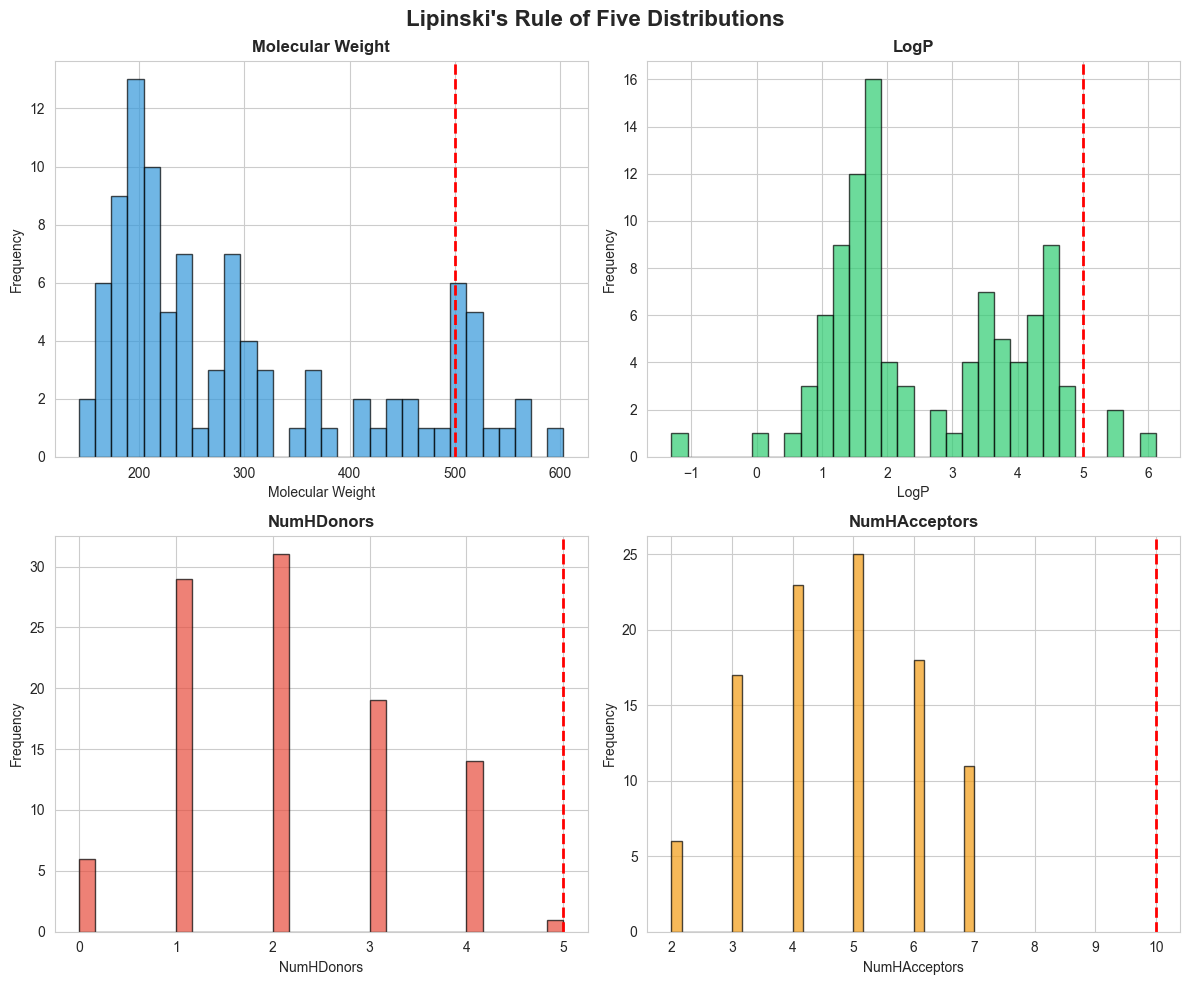

In [7]:
# ===== VISUALIZE: Lipinski's Rule of 5 Distributions =====

def compute_lipinski(smiles_list):
    rows = []
    for s in smiles_list:
        try:
            m = Chem.MolFromSmiles(s)
            if m is None:
                continue
            rows.append({
                'SMILES': s,
                'Molecular Weight': Descriptors.MolWt(m),
                'LogP': Crippen.MolLogP(m),
                'NumHDonors': Descriptors.NumHDonors(m),
                'NumHAcceptors': Descriptors.NumHAcceptors(m),
            })
        except Exception:
            continue
    return pd.DataFrame(rows)

desc_df = compute_lipinski(df['Smiles'].tolist()[:100])
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Lipinski's Rule of Five Distributions", fontsize=16, fontweight='bold')
axes = axes.ravel()
cols = ['Molecular Weight', 'LogP', 'NumHDonors', 'NumHAcceptors']
lims = [500, 5, 5, 10]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
for i, c in enumerate(cols):
    axes[i].hist(desc_df[c].dropna(), bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(c, fontweight='bold')
    axes[i].set_xlabel(c)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(lims[i], color='red', linestyle='--', linewidth=2)
plt.tight_layout()
out_file = OUT / 'lipinski_distributions.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight')
print(f'✓ Saved {out_file}')

Computing Morgan fingerprints for 200 molecules...


[16:20:42] DEPRECATION WARNING: please use MorganGenerator
[16:20:42] DEPRECATION WARNING: please use MorganGenerator
[16:20:42] DEPRECATION WARNING: please use MorganGenerator
[16:20:42] DEPRECATION WARNING: please use MorganGenerator
[16:20:42] DEPRECATION WARNING: please use MorganGenerator
[16:20:42] DEPRECATION WARNING: please use MorganGenerator
[16:20:42] DEPRECATION WARNING: please use MorganGenerator
[16:20:42] DEPRECATION WARNING: please use MorganGenerator
[16:20:42] DEPRECATION WARNING: please use MorganGenerator
[16:20:42] DEPRECATION WARNING: please use MorganGenerator
[16:20:42] DEPRECATION WARNING: please use MorganGenerator
[16:20:42] DEPRECATION WARNING: please use MorganGenerator
[16:20:42] DEPRECATION WARNING: please use MorganGenerator
[16:20:42] DEPRECATION WARNING: please use MorganGenerator
[16:20:42] DEPRECATION WARNING: please use MorganGenerator
[16:20:42] DEPRECATION WARNING: please use MorganGenerator
[16:20:42] DEPRECATION WARNING: please use MorganGenerat

✓ Generated fingerprints: shape (200, 1024)
✓ PCA explained variance: 11.9%
✓ Saved chemical space plot: /Users/ameliaburton/Downloads/clean data/clean_data_diss/results/figures/chemical_space_pca.png


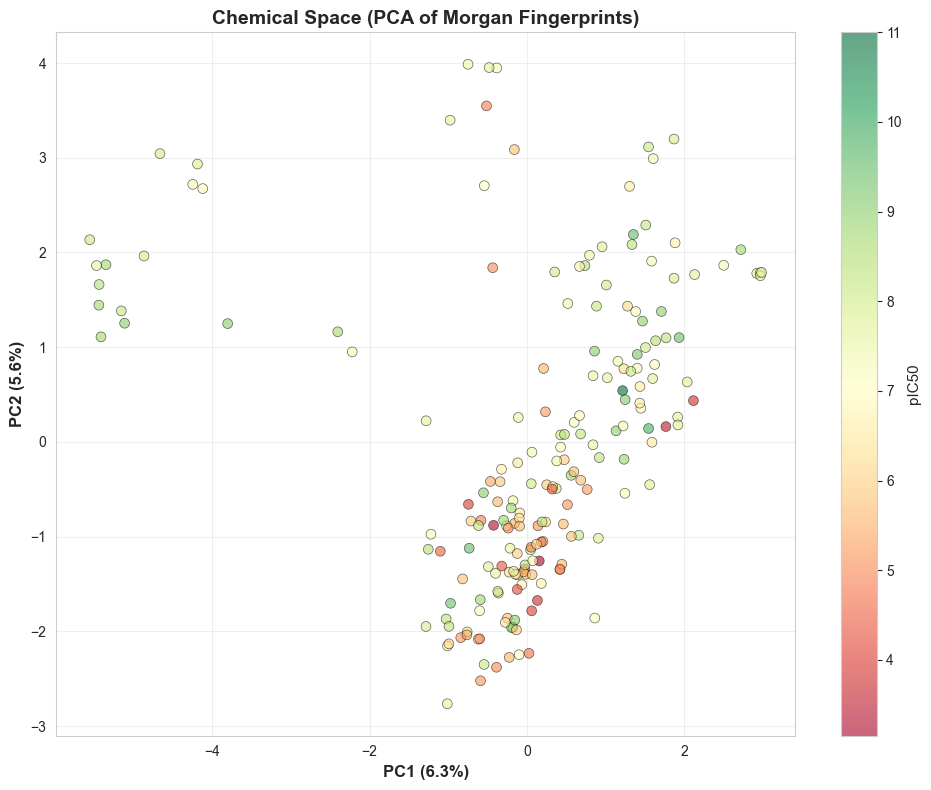

In [8]:
# ===== CHEMICAL SPACE: PCA OF MORGAN FINGERPRINTS =====

from rdkit.Chem import AllChem
from sklearn.decomposition import PCA

# Sample molecules for fingerprinting (limit to 200 for speed)
sample_size = min(200, len(df))
sample_mols = df['Smiles'].astype(str).sample(n=sample_size, random_state=42).tolist()

print(f'Computing Morgan fingerprints for {len(sample_mols)} molecules...')

fingerprints = []
valid_pic50 = []
for i, smiles in enumerate(sample_mols):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
        fingerprints.append(fp)
        # Get corresponding pIC50 if available
        if 'pChEMBL_Value' in df.columns:
            idx_in_orig = df[df['Smiles'] == smiles].index[0] if smiles in df['Smiles'].values else None
            if idx_in_orig is not None and not pd.isna(df.loc[idx_in_orig, 'pChEMBL_Value']):
                valid_pic50.append(df.loc[idx_in_orig, 'pChEMBL_Value'])
            else:
                valid_pic50.append(None)
        else:
            valid_pic50.append(None)

# Convert fingerprints to dense array
fp_array = np.array([np.array(list(fp)) for fp in fingerprints])
print(f'✓ Generated fingerprints: shape {fp_array.shape}')

# PCA to 2D
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(fp_array)
print(f'✓ PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}')

# Create scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

# Color by pIC50 if available
if any(v is not None for v in valid_pic50):
    pic50_vals = np.array([v if v is not None else np.nan for v in valid_pic50])
    valid_mask = ~np.isnan(pic50_vals)
    scatter = ax.scatter(pca_coords[valid_mask, 0], pca_coords[valid_mask, 1],
                        c=pic50_vals[valid_mask], cmap='RdYlGn', s=50, alpha=0.6,
                        edgecolors='black', linewidth=0.5)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('pIC50', fontsize=11)
    # Plot non-active points in gray
    unmapped = ~valid_mask
    if unmapped.any():
        ax.scatter(pca_coords[unmapped, 0], pca_coords[unmapped, 1],
                  c='lightgray', s=30, alpha=0.3, edgecolors='none')
else:
    ax.scatter(pca_coords[:, 0], pca_coords[:, 1], c='#3498db', s=50, alpha=0.6,
              edgecolors='black', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax.set_title('Chemical Space (PCA of Morgan Fingerprints)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
out_file = OUT / 'chemical_space_pca.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight')
print(f'✓ Saved chemical space plot: {out_file}')

In [9]:
# ===== TOP ACTIVES GRID: 2D STRUCTURES WITH CHEMICAL NAMES =====

from rdkit.Chem import Draw
import pubchempy as pcp

if 'pIC50' in df_global.columns and len(df) > 0:
    # Sort by pIC50 and get top 8 molecules
    top_n = 8
    top_actives = df_global.nlargest(top_n, 'pIC50')
    
    # Convert SMILES to molecules and fetch chemical names
    mols_list = []
    legends_list = []
    chem_data = []
    
    for idx, row in top_actives.iterrows():
        mol = Chem.MolFromSmiles(row['SMILES'])
        if mol is not None:
            mols_list.append(mol)
            
            # Try to fetch IUPAC name from PubChem
            try:
                compounds = pcp.get_compounds(row['SMILES'], namespace='smiles')
                if compounds:
                    iupac_name = compounds[0].iupac_name
                    # Shorten long names
                    names = [iupac_name.split(')')[-1], iupac_name.split(']')[-1]]
                    short_name = min(names, key=len)[:20]  # Truncate to 20 chars for display
                else:
                    short_name = f"pIC50: {row['pIC50']:.2f}"
            except Exception:
                short_name = f"pIC50: {row['pIC50']:.2f}"
            
            legends_list.append(short_name)
            chem_data.append({
                'Rank': len(chem_data) + 1,
                'pIC50': row['pIC50'],
                'MW': row['MolWt'],
                'LogP': row['LogP'],
                'Name': short_name,
                'SMILES': row['SMILES']
            })
    
    if mols_list:
        # Create grid image
        grid_img = Draw.MolsToGridImage(mols_list, molsPerRow=4, subImgSize=(200, 200),
                                        legends=legends_list, returnPNG=False)
        
        # Save image
        out_file = OUT / 'top_actives_grid.png'
        grid_img.save(out_file)
        print(f'✓ Saved top actives grid (n={len(mols_list)}): {out_file}')
        
        # Print detailed table
        print(f'\nTop {len(chem_data)} Most Potent Compounds:')
        print('─' * 80)
        for data in chem_data:
            print(f"  {data['Rank']}. {data['Name']}")
            print(f"     pIC50={data['pIC50']:.2f} | MW={data['MW']:.1f} | LogP={data['LogP']:.2f}")
            print(f"     SMILES: {data['SMILES'][:60]}...")
        print('─' * 80)
    else:
        print('⚠ Could not parse SMILES for top actives')
else:
    print('⚠ Insufficient data for top actives visualization')


✓ Saved top actives grid (n=8): /Users/ameliaburton/Downloads/clean data/clean_data_diss/results/figures/top_actives_grid.png

Top 8 Most Potent Compounds:
────────────────────────────────────────────────────────────────────────────────
  1. -6,7-diethoxyquinazo
     pIC50=11.22 | MW=388.3 | LogP=4.93
     SMILES: CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC...
  2. pyrimidine-4,6-diami
     pIC50=11.10 | MW=330.2 | LogP=3.57
     SMILES: CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1...
  3. quinazolin-8-amine
     pIC50=11.10 | MW=340.2 | LogP=4.01
     SMILES: Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1...
  4. pyrimidine-5-carboxy
     pIC50=11.10 | MW=562.7 | LogP=6.13
     SMILES: COc1cc(N2CCC(N(C)C)CC2)ccc1Nc1ncc(C(=O)Oc2ccccc2)c(-c2c[nH]c...
  5. quinazolin-8-amine
     pIC50=11.10 | MW=340.2 | LogP=4.01
     SMILES: Brc1cccc(Nc2ncnc3cc4nc[nH]c4cc23)c1...
  6. quinazoline
     pIC50=11.05 | MW=467.5 | LogP=3.02
     SMILES: COCCOc1cc2ncnc(Nc3cccc(OS(=O)(=O)F)c3)c2cc1OCCOC...
  7. quinazolin-8-amine
     pIC50

✓ Saved correlation heatmap: /Users/ameliaburton/Downloads/clean data/clean_data_diss/results/figures/descriptor_correlation_heatmap.png

Correlation with pIC50:
pIC50            1.000000
MolWt            0.334535
NumHAcceptors    0.283850
LogP             0.200504
NumHDonors       0.135579
Name: pIC50, dtype: float64


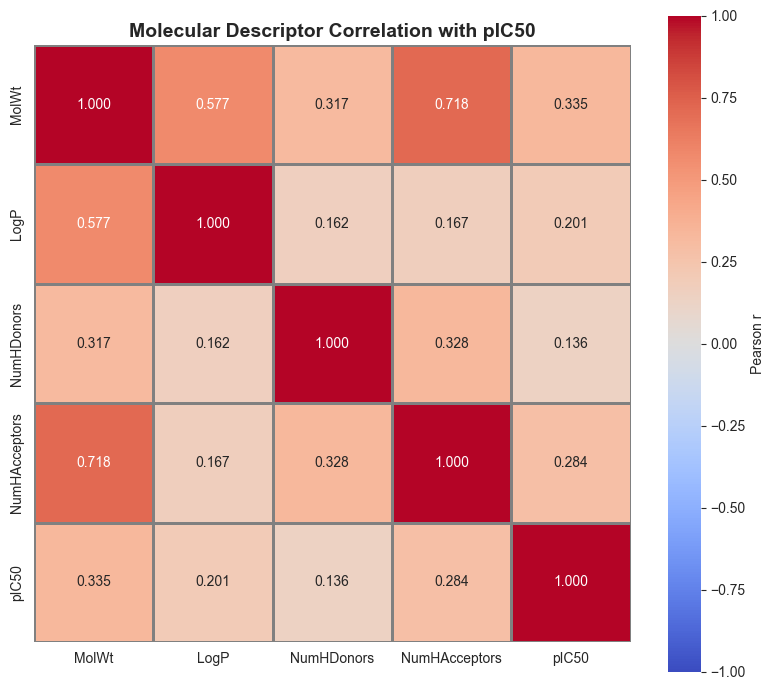

In [10]:
# ===== DESCRIPTOR CORRELATION HEATMAP =====

if 'pIC50' in df_global.columns:
    # Select key descriptors
    corr_cols = ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'pIC50']
    corr_data = df_global[corr_cols].dropna()
    
    # Compute Pearson correlation
    corr_matrix = corr_data.corr(method='pearson')
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
               vmin=-1, vmax=1, cbar_kws={'label': 'Pearson r'},
               square=True, linewidths=1, linecolor='gray', ax=ax)
    
    ax.set_title('Molecular Descriptor Correlation with pIC50', fontsize=14, fontweight='bold')
    plt.tight_layout()
    out_file = OUT / 'descriptor_correlation_heatmap.png'
    plt.savefig(out_file, dpi=300, bbox_inches='tight')
    print(f'✓ Saved correlation heatmap: {out_file}')
    print(f'\nCorrelation with pIC50:')
    print(corr_matrix['pIC50'].sort_values(ascending=False))
else:
    print('⚠ Cannot compute correlations: pIC50 column missing')

/var/folders/pc/8s1tc2r10qxbh34mff3zwvk80000gn/T/ipykernel_95676/1249380172.py:15: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pc/8s1tc2r10qxbh34mff3zwvk80000gn/T/ipykernel_95676/1249380172.py:15: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pc/8s1tc2r10qxbh34mff3zwvk80000gn/T/ipykernel_95676/1249380172.py:15: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pc/8s1tc2r10qxbh34mff3zwvk80000gn/T/ipykernel_95676/1249380172.py:17: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(out_file, dpi=300, bbox_inches='tight')
/var/folders/pc/8s1tc2r10qxbh34mff3zwvk80000gn/T/ipykernel_95676/1249380172.py:17: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(out_file, dpi=300, bbox_inches='tight')
/var/folders/pc/8s1tc2r10qxbh34mff3zwvk80000gn/T/ip

✓ Saved pIC50 distribution: /Users/ameliaburton/Downloads/clean data/clean_data_diss/results/figures/pic50_distribution.png

pIC50 Statistics:
  Mean: 7.08
  Std:  1.40
  Min:  2.85
  Max:  11.22


/Users/ameliaburton/Downloads/clean data/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ameliaburton/Downloads/clean data/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ameliaburton/Downloads/clean data/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


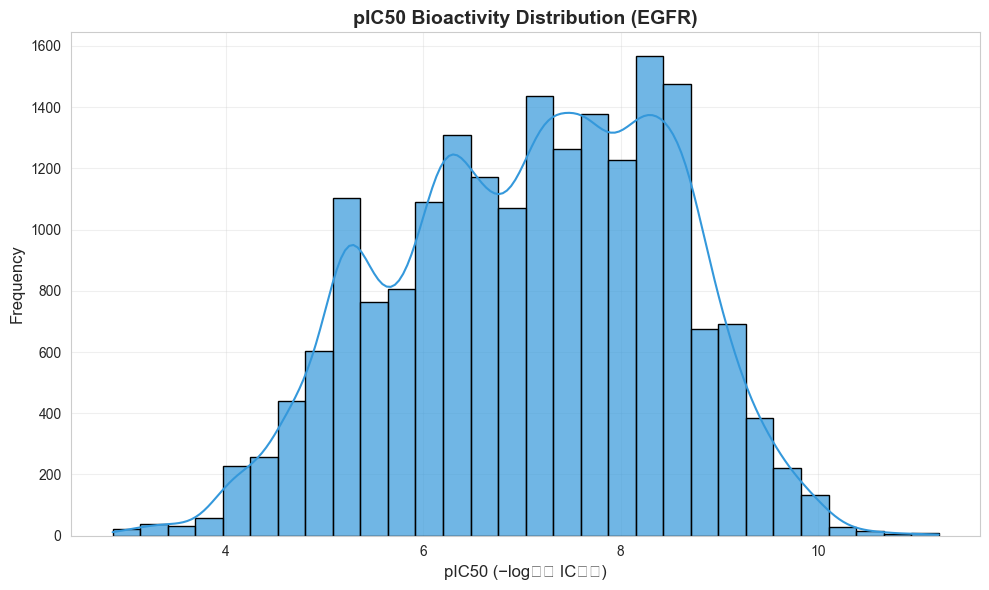

In [11]:
# ===== ADVANCED EDA: pIC50 BIOACTIVITY DISTRIBUTION =====

if 'pIC50' in df_global.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Histogram + KDE overlay
    sns.histplot(data=df_global, x='pIC50', kde=True, bins=30, 
                color='#3498db', edgecolor='black', alpha=0.7, ax=ax)
    
    ax.set_title('pIC50 Bioactivity Distribution (EGFR)', fontsize=14, fontweight='bold')
    ax.set_xlabel('pIC50 (−log₁₀ IC₅₀)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    out_file = OUT / 'pic50_distribution.png'
    plt.savefig(out_file, dpi=300, bbox_inches='tight')
    print(f'✓ Saved pIC50 distribution: {out_file}')
    
    # Summary statistics
    print(f'\npIC50 Statistics:')
    print(f'  Mean: {df_global["pIC50"].mean():.2f}')
    print(f'  Std:  {df_global["pIC50"].std():.2f}')
    print(f'  Min:  {df_global["pIC50"].min():.2f}')
    print(f'  Max:  {df_global["pIC50"].max():.2f}')
else:
    print('⚠ pIC50 column not found in dataframe')

In [12]:
from rdkit.Chem import AllChem, rdPartialCharges, rdMolDescriptors, Lipinski
from rdkit.Chem import rdFingerprintGenerator
from scipy.spatial import ConvexHull

# ===== GRAPH CONVERSION: SMILES to PyG graph =====
morgan_fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def get_node_features(atom):
    partial_charge = 0.0
    try:
        if atom.HasProp('_GasteigerCharge'):
            charge_value = float(atom.GetProp('_GasteigerCharge'))
            if np.isfinite(charge_value):
                partial_charge = charge_value
    except Exception:
        partial_charge = 0.0
    return [
        atom.GetAtomicNum(),
        int(atom.GetTotalDegree()),
        atom.GetFormalCharge(),
        int(atom.GetHybridization()),
        int(atom.GetIsAromatic()),
        atom.GetMass(),
        int(atom.GetChiralTag()),
        partial_charge,
    ]

def get_edge_features(bond):
    bond_type = bond.GetBondType()
    stereo_flag = int(bond.GetStereo() != Chem.rdchem.BondStereo.STEREONONE)
    return [
        int(bond_type == Chem.rdchem.BondType.SINGLE),
        int(bond_type == Chem.rdchem.BondType.DOUBLE),
        int(bond_type == Chem.rdchem.BondType.TRIPLE),
        int(bond_type == Chem.rdchem.BondType.AROMATIC),
        stereo_flag,
    ]

def compute_v1_feature_pack(mol, coords_heavy):
    """20 low-dimensional, physics-grounded global molecular features."""
    eps = 1e-8
    heavy = max(1, mol.GetNumHeavyAtoms())
    try:
        rdPartialCharges.ComputeGasteigerCharges(mol)
    except Exception:
        pass

    charges = []
    for atom in mol.GetAtoms():
        charge = 0.0
        try:
            if atom.HasProp('_GasteigerCharge'):
                value = float(atom.GetProp('_GasteigerCharge'))
                if np.isfinite(value):
                    charge = value
        except Exception:
            charge = 0.0
        charges.append(charge)
    charges = np.array(charges, dtype=np.float32) if charges else np.zeros(1, dtype=np.float32)

    if coords_heavy is not None and coords_heavy.shape[0] >= 3 and np.any(coords_heavy != 0):
        centered = coords_heavy - coords_heavy.mean(axis=0, keepdims=True)
        rg = float(np.sqrt(np.mean(np.sum(centered ** 2, axis=1))))
        cov = np.cov(centered.T)
        eig = np.sort(np.maximum(np.linalg.eigvalsh(cov), 0.0))[::-1]
        l1, l2, l3 = float(eig[0]), float(eig[1]), float(eig[2])
        asphericity = float(((l1 - l2) ** 2 + (l2 - l3) ** 2 + (l3 - l1) ** 2) / (2.0 * (l1 + l2 + l3) ** 2 + eps))
        npr1 = float(l3 / (l1 + eps))
        npr2 = float(l2 / (l1 + eps))
    else:
        rg, asphericity, npr1, npr2 = 0.0, 0.0, 0.0, 0.0

    aromatic_atoms = sum(int(atom.GetIsAromatic()) for atom in mol.GetAtoms())
    hetero_atoms = sum(int(atom.GetAtomicNum() not in (1, 6)) for atom in mol.GetAtoms())
    feats = np.array([
        float(Descriptors.MolWt(mol)),
        float(Crippen.MolLogP(mol)),
        float(Descriptors.TPSA(mol)),
        float(Descriptors.NumHDonors(mol)),
        float(Descriptors.NumHAcceptors(mol)),
        float(Descriptors.NumRotatableBonds(mol)),
        float(rdMolDescriptors.CalcNumRings(mol)),
        float(Lipinski.FractionCSP3(mol)),
        float(mol.GetNumHeavyAtoms()),
        float(hetero_atoms),
        float(hetero_atoms / heavy),
        float(aromatic_atoms / max(1, mol.GetNumAtoms())),
        float(sum(atom.GetFormalCharge() for atom in mol.GetAtoms())),
        float(Descriptors.NumValenceElectrons(mol)),
        float(np.mean(charges)),
        float(np.std(charges)),
        rg,
        asphericity,
        npr1,
        npr2,
    ], dtype=np.float32)
    return feats

def smiles_to_graph(smiles):
    mol_base = Chem.MolFromSmiles(smiles)
    if mol_base is None:
        return None

    mol = Chem.Mol(mol_base)
    try:
        mol_3d = Chem.AddHs(Chem.Mol(mol_base))
        embed_status = AllChem.EmbedMolecule(mol_3d, randomSeed=42)
        if embed_status == 0:
            rdPartialCharges.ComputeGasteigerCharges(mol)
            try:
                AllChem.MMFFOptimizeMolecule(mol_3d)
            except Exception:
                pass

            conf = mol_3d.GetConformer()
            heavy_atom_indices = [atom.GetIdx() for atom in mol_3d.GetAtoms() if atom.GetAtomicNum() > 1]
            coords = []
            for idx in heavy_atom_indices:
                p = conf.GetAtomPosition(idx)
                coords.append([p.x, p.y, p.z])
            if len(coords) == mol.GetNumAtoms():
                coords_heavy = np.array(coords, dtype=np.float32)
            else:
                coords_heavy = np.zeros((mol.GetNumAtoms(), 3), dtype=np.float32)
        else:
            coords_heavy = np.zeros((mol.GetNumAtoms(), 3), dtype=np.float32)
    except Exception:
        coords_heavy = np.zeros((mol.GetNumAtoms(), 3), dtype=np.float32)

    x = [get_node_features(atom) for atom in mol.GetAtoms()]
    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.extend([[i, j], [j, i]])
        features = get_edge_features(bond)
        edge_attr.extend([features, features])

    try:
        fp = morgan_fpgen.GetFingerprint(mol)
        fp_arr = np.array(list(fp.ToBitString()), dtype=np.int8).astype(np.float32)
    except Exception:
        fp_arr = np.zeros(1024, dtype=np.float32)

    v1_feats = compute_v1_feature_pack(mol, coords_heavy)
    edge_index_tensor = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    data = Data(
        x=torch.tensor(x, dtype=torch.float),
        edge_index=edge_index_tensor,
        edge_attr=torch.tensor(edge_attr, dtype=torch.float),
        pos=torch.tensor(coords_heavy, dtype=torch.float),
    )
    data.global_features = torch.tensor(v1_feats, dtype=torch.float32).unsqueeze(0)
    try:
        data.fingerprint = torch.tensor(fp_arr, dtype=torch.float32)
    except Exception:
        data.fingerprint = torch.zeros(1024, dtype=torch.float32)
    return data

# Convert FULL EGFR dataset to graphs (no slice-process entire dataset)
sample_smiles = df['Smiles'].astype(str).tolist()
graphs = []
for i, s in enumerate(sample_smiles):
    g = smiles_to_graph(s)
    if g is not None:
        try:
            g.SMILES = s
        except Exception:
            pass
        try:
            g.orig_index = int(i)
        except Exception:
            pass
        graphs.append(g)

print(f'Prepared {len(graphs)} PyG graphs with 3D coordinates (8 node + 5 edge features + 20 global + 3D pos)')

# Save for downstream notebooks (overwrite if exists)
if graphs:
    graph_file = DATA_PROCESSED / 'graph_data.pt'
    torch.save(graphs, str(graph_file))
    print(f'Saved {len(graphs)} graphs to {graph_file}')

# ===== POCKET FEATURES: 3D Protein Structure Encoding =====
_KD_SCALE = {
    'A': 1.8, 'R': -4.5, 'N': -3.5, 'D': -3.5, 'C': 2.5,
    'Q': -3.5, 'E': -3.5, 'G': -0.4, 'H': -3.2, 'I': 4.5,
    'L': 3.8, 'K': -3.9, 'M': 1.9, 'F': 2.8, 'P': -1.6,
    'S': -0.8, 'T': -0.7, 'W': -0.9, 'Y': -1.3, 'V': 4.2
}
_RES_CHARGE = {'ASP': -1.0, 'GLU': -1.0, 'LYS': 1.0, 'ARG': 1.0, 'HIS': 0.1}

def compute_pocket_tensor(coords, residue_names=None, embedding_dim=133):
    """Squashes variable-sized protein pocket into a fixed embedding."""
    if coords is None or coords.size == 0:
        return torch.zeros(embedding_dim, dtype=torch.float32)

    centroid = coords.mean(axis=0)
    std_dev = coords.std(axis=0)
    max_spread = coords.max(axis=0) - coords.min(axis=0)
    feat = np.concatenate([centroid, std_dev, max_spread])

    hydrophobicities = []
    net_charge = 0.0
    if residue_names:
        for resname in residue_names:
            one = resname[0].upper() if len(resname) >= 1 else resname.upper()
            if one in _KD_SCALE:
                hydrophobicities.append(_KD_SCALE[one])
            net_charge += _RES_CHARGE.get(resname.upper(), 0.0)
    if hydrophobicities:
        hyd_mean = float(np.mean(hydrophobicities))
        hyd_std = float(np.std(hydrophobicities))
    else:
        hyd_mean, hyd_std = 0.0, 0.0

    try:
        if coords.shape[0] >= 4:
            hull = ConvexHull(coords)
            hull_volume = float(hull.volume)
        else:
            hull_volume = 0.0
    except Exception:
        hull_volume = 0.0
    pocket_depth = float(np.max(np.linalg.norm(coords - centroid, axis=1))) if coords.size else 0.0
    extra = np.array([hyd_mean, hyd_std, net_charge, hull_volume, pocket_depth], dtype=float)
    feat = np.concatenate([feat, extra])
    feat = np.pad(feat, (0, max(0, embedding_dim - feat.size)), mode='constant')[:embedding_dim]
    return torch.tensor(feat, dtype=torch.float32)

# Example pocket (12 protein atoms) - demonstration only
pocket_coords = np.array([
    [0.0, 0.0, 0.0], [2.5, 3.1, 2.2], [7.2, 6.8, 7.5], [9.5, 10.1, 9.3],
    [1.2, 4.5, 3.8], [8.1, 5.9, 6.2], [3.4, 7.2, 4.1], [6.8, 2.3, 8.9],
    [4.1, 8.5, 5.6], [7.9, 4.1, 3.2], [2.0, 6.0, 7.0], [8.5, 7.5, 4.5],
])
pocket_embedding = compute_pocket_tensor(pocket_coords, embedding_dim=133)
print('\n' + '=' * 60)
print('POCKET FEATURES (Reference Implementation)')
print('=' * 60)
print(f'Input: {pocket_coords.shape} coordinate cloud')
print(f'Output: {pocket_embedding.shape} fixed embedding')
print(f'  Spatial stats (9 features): {pocket_embedding[:9].numpy()}')
print(f'  Extra scalars (hyd_mean, hyd_std, net_charge, hull_vol, depth): {pocket_embedding[9:14].numpy()}')
print('Pocket encoding ready for VAE conditioning')

[16:21:04] UFFTYPER: Unrecognized charge state for atom: 2
[16:21:38] UFFTYPER: Unrecognized charge state for atom: 1
[16:22:21] UFFTYPER: Unrecognized charge state for atom: 1
[16:22:58] UFFTYPER: Unrecognized charge state for atom: 1
[16:22:58] UFFTYPER: Unrecognized charge state for atom: 1
[16:22:58] UFFTYPER: Unrecognized charge state for atom: 1
[16:22:58] UFFTYPER: Unrecognized charge state for atom: 1
[16:23:08] UFFTYPER: Unrecognized charge state for atom: 1
[16:25:23] UFFTYPER: Unrecognized charge state for atom: 0
[16:25:23] UFFTYPER: Unrecognized atom type: Zn+2 (0)
[16:26:29] UFFTYPER: Unrecognized charge state for atom: 22
[16:26:32] UFFTYPER: Unrecognized charge state for atom: 1
[16:27:30] UFFTYPER: Unrecognized charge state for atom: 1
[16:27:47] UFFTYPER: Unrecognized charge state for atom: 33
[16:27:47] UFFTYPER: Unrecognized charge state for atom: 8
[16:28:16] UFFTYPER: Unrecognized charge state for atom: 31
[16:28:16] UFFTYPER: Unrecognized charge state for atom: 6

Prepared 19476 PyG graphs with 3D coordinates (8 node + 5 edge features + 20 global + 3D pos)
Saved 19476 graphs to /Users/ameliaburton/Downloads/clean data/clean_data_diss/data/processed/graph_data.pt

POCKET FEATURES (Reference Implementation)
Input: (12, 3) coordinate cloud
Output: torch.Size([133]) fixed embedding
  Spatial stats (9 features): [ 5.1        5.5        5.1916666  3.1163547  2.7135463  2.6440053
  9.5       10.1        9.3      ]
  Extra scalars (hyd_mean, hyd_std, net_charge, hull_vol, depth): [  0.         0.         0.       171.865      9.122138]
Pocket encoding ready for VAE conditioning


✓ Visualizing graph topology for example molecules...
✓ Saved graph structure visualization: /Users/ameliaburton/Downloads/clean data/clean_data_diss/results/figures/graph_structure_examples.png

✓ Graph topology summary for selected examples:
  First Graph (index 0):
    - Nodes: 27, Edges: 60
    - Avg degree: 4.4
    - Has 3D coords: True
  Middle Graph (index 9738):
    - Nodes: 49, Edges: 110
    - Avg degree: 4.5
    - Has 3D coords: True
  Largest Graph (index 7251):
    - Nodes: 103, Edges: 220
    - Avg degree: 4.3
    - Has 3D coords: True


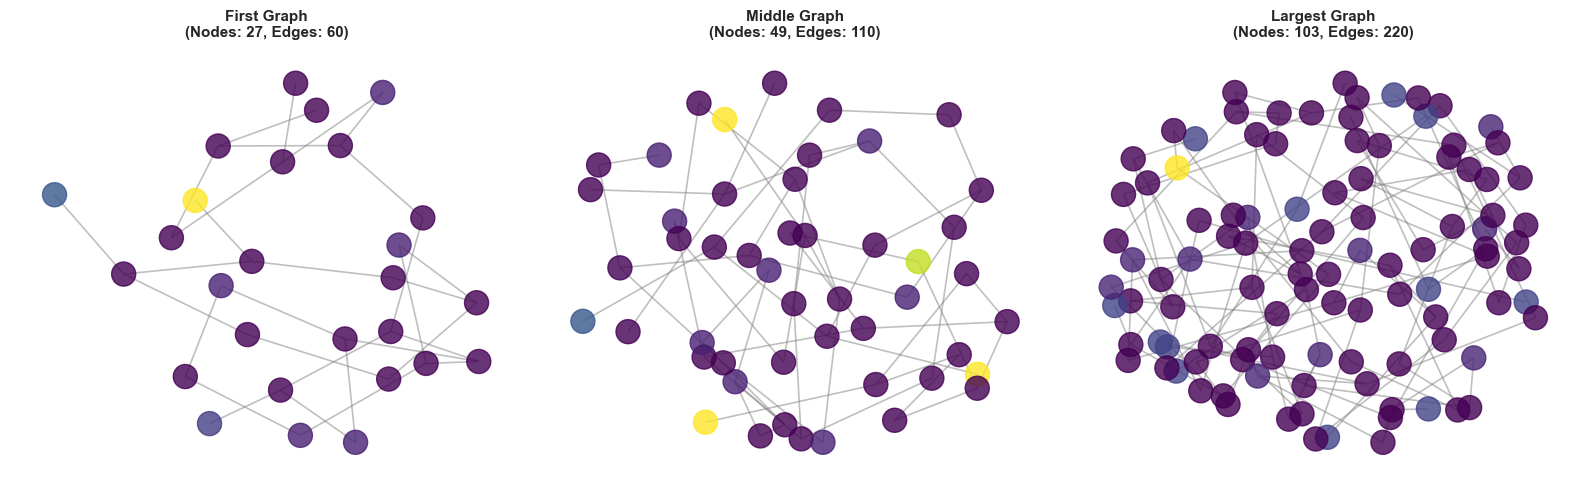

In [13]:
# ===== GRAPH STRUCTURE VISUALIZATION: NetworkX Examples =====

from torch_geometric.utils import to_networkx
import networkx as nx

if 'graphs' in globals() and len(graphs) > 2:
    print('✓ Visualizing graph topology for example molecules...')
    
    # Select example graphs (first, middle, one with most nodes)
    idx_first = 0
    idx_middle = len(graphs) // 2
    idx_largest = max(range(len(graphs)), key=lambda i: graphs[i].num_nodes)
    selected_indices = [idx_first, idx_middle, idx_largest]
    selected_graphs = [graphs[i] for i in selected_indices]
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    titles = ['First Graph', 'Middle Graph', 'Largest Graph']
    
    for ax_idx, (g, title, orig_idx) in enumerate(zip(selected_graphs, titles, selected_indices)):
        # Convert to NetworkX, repairing legacy Ex2 edge_index tensors if needed
        if hasattr(g, 'edge_index') and g.edge_index is not None and g.edge_index.dim() == 2 and g.edge_index.size(0) != 2 and g.edge_index.size(1) == 2:
            edge_index = g.edge_index.t().contiguous()
        else:
            edge_index = g.edge_index
        if edge_index is None or edge_index.numel() == 0:
            G = nx.Graph()
            G.add_nodes_from(range(g.num_nodes))
        else:
            G = to_networkx(Data(x=g.x, edge_index=edge_index), to_undirected=True)
        
        # Compute layout
        pos = nx.spring_layout(G, seed=42, k=0.5, iterations=30)
        
        # Node colors based on atomic number (first feature)
        if hasattr(g, 'x') and g.x is not None:
            atomic_nums = g.x[:, 0].cpu().numpy().astype(int)
            node_colors = [atomic_nums[i] for i in range(len(atomic_nums))]
        else:
            node_colors = '#87CEEB'
        
        # Draw
        ax = axes[ax_idx]
        nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300,
                              cmap='viridis', ax=ax, alpha=0.8)
        nx.draw_networkx_edges(G, pos, width=1.2, alpha=0.5, ax=ax, edge_color='gray')
        
        ax.set_title(f'{title}\n(Nodes: {g.num_nodes}, Edges: {g.num_edges})',
                    fontweight='bold', fontsize=11)
        ax.axis('off')
    
    plt.tight_layout()
    graph_viz_out = OUT / 'graph_structure_examples.png'
    plt.savefig(graph_viz_out, dpi=300, bbox_inches='tight')
    print(f'✓ Saved graph structure visualization: {graph_viz_out}')
    
    # Print summary
    print('\n✓ Graph topology summary for selected examples:')
    for i, (g, title, orig_idx) in enumerate(zip(selected_graphs, titles, selected_indices)):
        print(f'  {title} (index {orig_idx}):')
        print(f'    - Nodes: {g.num_nodes}, Edges: {g.num_edges}')
        print(f'    - Avg degree: {2 * g.num_edges / g.num_nodes:.1f}')
        if hasattr(g, 'pos') and g.pos is not None:
            has_3d = torch.any(g.pos != 0).item()
            print(f'    - Has 3D coords: {has_3d}')
else:
    print('⚠ Graphs not available for visualization')
